findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/Users/zhaoyian/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) miss

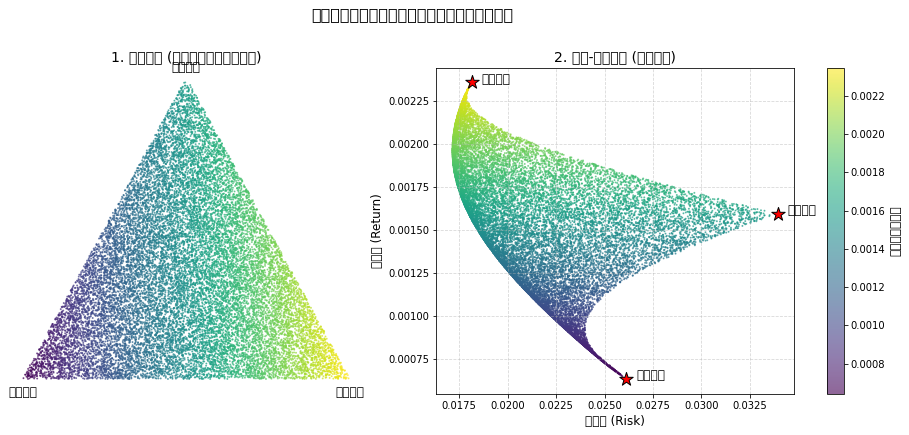

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Windows用黑体，Mac用户请改为 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

# 1. 导入你提供的真实数据
# 资产顺序：[科大讯飞, 贵州茅台, 药明康德]
returns = np.array([0.00063598, 0.00235508, 0.00159318]) 

# 对称协方差矩阵补全
cov_matrix = np.array([
    [0.00068277, 0.00018373, 0.00032823],
    [0.00018373, 0.00032969, 0.00023092],
    [0.00032823, 0.00023092, 0.00115149]
])

# 2. 蒙特卡洛模拟：生成均匀分布的权重
n_simulations = 20000  # 增加点数让边缘更清晰
weights = np.random.dirichlet(np.ones(3), size=n_simulations)

# 3. 计算每个组合的收益率和波动率
port_returns = np.dot(weights, returns)
port_risks = np.zeros(n_simulations)
for i in range(n_simulations):
    port_risks[i] = np.sqrt(np.dot(weights[i].T, np.dot(cov_matrix, weights[i])))

# 4. 绘图准备：将3D权重(w1,w2,w3)投影到2D等边三角形平面上
# 左下: 科大讯飞(0,0)，右下: 贵州茅台(1,0)，正上: 药明康德(0.5, 0.866)
x_triangle = weights[:, 1] + 0.5 * weights[:, 2]
y_triangle = (np.sqrt(3) / 2) * weights[:, 2]

# 5. 开始绘图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 左图：权重三角形
scatter1 = ax1.scatter(x_triangle, y_triangle, c=port_returns, cmap='viridis', s=1, alpha=0.6)
ax1.set_title("1. 权重空间 (均匀分布的等边三角形)", fontsize=14)
ax1.text(0, -0.05, '科大讯飞', ha='center', fontsize=12, fontweight='bold')
ax1.text(1, -0.05, '贵州茅台', ha='center', fontsize=12, fontweight='bold')
ax1.text(0.5, np.sqrt(3)/2 + 0.02, '药明康德', ha='center', fontsize=12, fontweight='bold')
ax1.axis('off') 

# 右图：风险-收益散点图
scatter2 = ax2.scatter(port_risks, port_returns, c=port_returns, cmap='viridis', s=1, alpha=0.6)
ax2.set_title("2. 风险-收益空间 (有效前沿)", fontsize=14)
ax2.set_xlabel("波动率 (Risk)", fontsize=12)
ax2.set_ylabel("收益率 (Return)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

# 标注三个单一资产在右图中的位置
asset_names = ['科大讯飞', '贵州茅台', '药明康德']
asset_risks = np.sqrt(np.diag(cov_matrix))
for i in range(3):
    ax2.scatter(asset_risks[i], returns[i], color='red', marker='*', s=200, edgecolor='black', zorder=5)
    ax2.text(asset_risks[i] + 0.0005, returns[i], asset_names[i], fontsize=12, fontweight='bold')

# 添加颜色条
cbar = fig.colorbar(scatter2, ax=[ax1, ax2], orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('组合预期收益率', fontsize=12)

plt.suptitle("真实数据模拟：科大讯飞、贵州茅台、药明康德", fontsize=16, y=1.02)
plt.show()

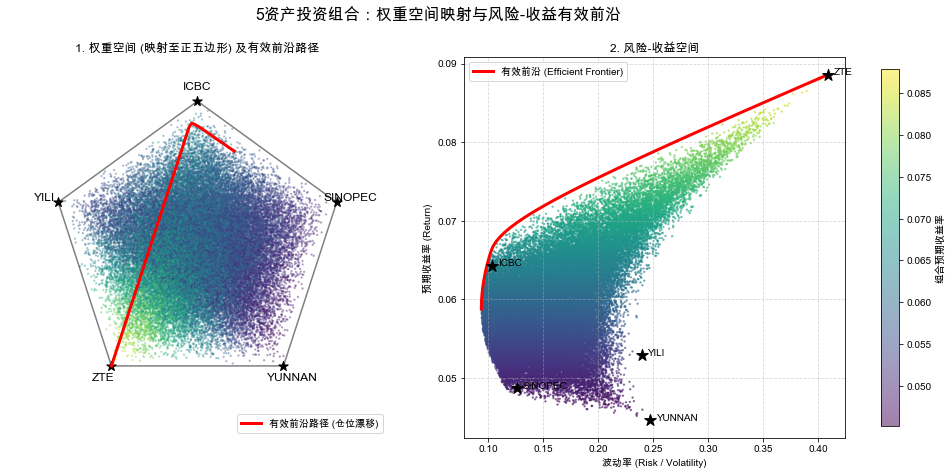

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sco
import matplotlib as mpl

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1. 录入数据
assets = ['ICBC', 'YILI', 'ZTE', 'YUNNAN', 'SINOPEC']
returns = np.array([0.0643, 0.0529, 0.0886, 0.0446, 0.0487])
vols = np.array([0.1035, 0.2398, 0.4094, 0.2474, 0.1260])

corr_matrix = np.array([
    [1.0000, 0.2241, 0.0662, 0.1621, 0.4697],
    [0.2241, 1.0000, 0.2832, 0.4642, 0.1518],
    [0.0662, 0.2832, 1.0000, 0.2713, 0.1455],
    [0.1621, 0.4642, 0.2713, 1.0000, 0.1695],
    [0.4697, 0.1518, 0.1455, 0.1695, 1.0000]
])

# 计算协方差矩阵: Cov(i,j) = Corr(i,j) * Vol(i) * Vol(j)
cov_matrix = np.outer(vols, vols) * corr_matrix

# 2. 蒙特卡洛模拟 (生成 50000 个随机组合)
num_portfolios = 50000
# 使用 Dirichlet 分布在单纯形上均匀采样
weights = np.random.dirichlet(np.ones(len(assets)), size=num_portfolios)

port_returns = np.dot(weights, returns)
port_vols = np.sqrt(np.einsum('ij,ji->i', np.dot(weights, cov_matrix), weights.T))

# 3. 计算有效前沿 (Efficient Frontier)
def portfolio_volatility(w):
    return np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))

def portfolio_return(w):
    return np.dot(w, returns)

# 寻找全局最小方差组合 (GMV)
cons_gmv = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bnds = tuple((0, 1) for _ in range(len(assets)))
init_guess = np.array(len(assets) * [1. / len(assets)])
opt_gmv = sco.minimize(portfolio_volatility, init_guess, method='SLSQP', bounds=bnds, constraints=cons_gmv)
min_vol_ret = portfolio_return(opt_gmv.x)
max_ret = np.max(returns)

# 在最小方差收益和最大收益之间生成目标收益率
target_returns = np.linspace(min_vol_ret, max_ret, 50)
ef_vols = []
ef_weights = []

for tr in target_returns:
    cons = ({'type': 'eq', 'fun': lambda x: portfolio_return(x) - tr},
            {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    res = sco.minimize(portfolio_volatility, init_guess, method='SLSQP', bounds=bnds, constraints=cons)
    ef_vols.append(res.fun)
    ef_weights.append(res.x)

ef_vols = np.array(ef_vols)
ef_weights = np.array(ef_weights)

# 4. 将 5 维权重映射到 2D 正五边形
# 计算正五边形的 5 个顶点坐标 (顶部开始，逆时针)
angles = np.linspace(0, 2 * np.pi, len(assets) + 1)[:-1] + np.pi / 2
vertices = np.column_stack((np.cos(angles), np.sin(angles)))

# 将所有随机组合的权重映射到 2D 坐标
mapped_x = np.dot(weights, vertices[:, 0])
mapped_y = np.dot(weights, vertices[:, 1])

# 将有效前沿的权重映射到 2D 坐标
ef_mapped_x = np.dot(ef_weights, vertices[:, 0])
ef_mapped_y = np.dot(ef_weights, vertices[:, 1])

# 5. 可视化绘图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('5资产投资组合：权重空间映射与风险-收益有效前沿', fontsize=16)

# --- 左图：五边形权重空间 ---
sc1 = ax1.scatter(mapped_x, mapped_y, c=port_returns, cmap='viridis', s=2, alpha=0.3)
# 绘制五边形边界
polygon = plt.Polygon(vertices, fill=False, edgecolor='black', linewidth=1.5, alpha=0.5)
ax1.add_patch(polygon)
# 绘制有效前沿路径
ax1.plot(ef_mapped_x, ef_mapped_y, color='red', linewidth=3, label='有效前沿路径 (仓位漂移)')
# 标记顶点
for i, asset in enumerate(assets):
    ax1.text(vertices[i, 0] * 1.1, vertices[i, 1] * 1.1, asset, fontsize=12, ha='center', va='center', fontweight='bold')
    ax1.scatter(vertices[i, 0], vertices[i, 1], color='black', marker='*', s=100)

ax1.set_xlim(-1.3, 1.3)
ax1.set_ylim(-1.3, 1.3)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('1. 权重空间 (映射至正五边形) 及有效前沿路径')
ax1.legend(loc='lower right')

# --- 右图：风险-收益空间 ---
sc2 = ax2.scatter(port_vols, port_returns, c=port_returns, cmap='viridis', s=2, alpha=0.5)
# 绘制有效前沿曲线
ax2.plot(ef_vols, target_returns, color='red', linewidth=3, label='有效前沿 (Efficient Frontier)')
# 标记单一资产
for i, asset in enumerate(assets):
    ax2.scatter(vols[i], returns[i], color='black', marker='*', s=150, zorder=5)
    ax2.text(vols[i] + 0.005, returns[i], asset, fontsize=10, fontweight='bold')

ax2.set_xlabel('波动率 (Risk / Volatility)')
ax2.set_ylabel('预期收益率 (Return)')
ax2.set_title('2. 风险-收益空间')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

# 添加 Colorbar
cbar = fig.colorbar(sc2, ax=[ax1, ax2], fraction=0.02, pad=0.04)
cbar.set_label('组合预期收益率')

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/Users/zhaoyian/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) miss

系统性抽样生成的投资组合数量: 23751


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

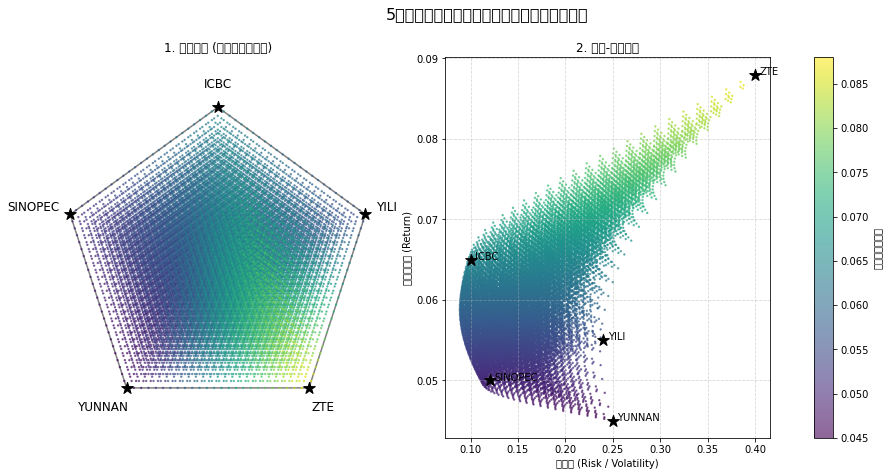

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

# ==========================================
# 1. 模拟资产数据 (假设数据，为了还原你的图表形态)
# ==========================================
assets = ['ICBC', 'SINOPEC', 'YUNNAN', 'ZTE', 'YILI']
num_assets = len(assets)

# 模拟预期收益率 (ZTE最高，SINOPEC/YUNNAN较低)
expected_returns = np.array([0.065, 0.050, 0.045, 0.088, 0.055])

# 模拟协方差矩阵 (ZTE波动率最大，ICBC/SINOPEC较小)
# 这里用一个简单的对角阵加上一些基础相关性来模拟
vols = np.array([0.10, 0.12, 0.25, 0.40, 0.24]) 
corr_matrix = np.array([
    [1.0, 0.4, 0.1, 0.2, 0.3],
    [0.4, 1.0, 0.2, 0.1, 0.2],
    [0.1, 0.2, 1.0, 0.3, 0.1],
    [0.2, 0.1, 0.3, 1.0, 0.4],
    [0.3, 0.2, 0.1, 0.4, 1.0]
])
cov_matrix = np.outer(vols, vols) * corr_matrix

# ==========================================
# 2. 系统性网格抽样 (核心改进部分)
# ==========================================
def generate_systematic_weights(num_assets, steps):
    """
    使用“隔板法”生成所有可能的权重组合
    steps: 把 100% 分成多少份。例如 steps=20，则步长为 5%
    """
    weights = []
    # itertools.combinations 结合隔板法，生成所有和为 steps 的非负整数序列
    for c in itertools.combinations(range(steps + num_assets - 1), num_assets - 1):
        weight = np.array([b - a - 1 for a, b in zip((-1,) + c, c + (steps + num_assets - 1,))])
        weights.append(weight / steps)
    return np.array(weights)

# 设置步长：将100%分为25份，每份4%。
# 组合数 = C(5+25-1, 25) = C(29, 25) = 23,751 个点
# 这个数量既能完美铺满边界，又不会太卡
steps = 25 
weights = generate_systematic_weights(num_assets, steps)
print(f"系统性抽样生成的投资组合数量: {len(weights)}")

# ==========================================
# 3. 计算投资组合的风险与收益
# ==========================================
port_returns = np.dot(weights, expected_returns)
# 计算所有组合的波动率 (使用爱因斯坦求和约定加速计算矩阵乘法)
port_vols = np.sqrt(np.einsum('ij,jk,ik->i', weights, cov_matrix, weights))

# ==========================================
# 4. 权重空间的正五边形映射计算
# ==========================================
# 计算正五边形的5个顶点坐标 (让ICBC在正上方)
angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, num_assets, endpoint=False)
pentagon_x = np.cos(angles)
pentagon_y = np.sin(angles)

# 将每个投资组合的权重映射到二维坐标 (加权平均)
mapped_x = np.dot(weights, pentagon_x)
mapped_y = np.dot(weights, pentagon_y)

# ==========================================
# 5. 绘图
# ==========================================
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- 图1：权重空间 ---
# 绘制五边形边界
pentagon_x_closed = np.append(pentagon_x, pentagon_x[0])
pentagon_y_closed = np.append(pentagon_y, pentagon_y[0])
ax1.plot(pentagon_x_closed, pentagon_y_closed, color='gray', zorder=1)

# 绘制系统性抽样的散点
sc1 = ax1.scatter(mapped_x, mapped_y, c=port_returns, cmap='viridis', s=2, alpha=0.6, zorder=2)

# 标注顶点
for i, asset in enumerate(assets):
    ax1.scatter(pentagon_x[i], pentagon_y[i], color='black', marker='*', s=150, zorder=3)
    # 调整文字位置避免重叠
    offset_x = 1.15 if pentagon_x[i] > 0 else 1.25
    offset_y = 1.15 if pentagon_y[i] > 0 else 1.15
    ax1.text(pentagon_x[i]*offset_x, pentagon_y[i]*offset_y, asset, ha='center', va='center', fontsize=12)

ax1.set_title('1. 权重空间 (系统性网格抽样)')
ax1.axis('equal')
ax1.axis('off') # 隐藏坐标轴

# --- 图2：风险-收益空间 ---
sc2 = ax2.scatter(port_vols, port_returns, c=port_returns, cmap='viridis', s=2, alpha=0.6)

# 标注单一资产点
for i, asset in enumerate(assets):
    ax2.scatter(vols[i], expected_returns[i], color='black', marker='*', s=150, zorder=3)
    ax2.text(vols[i] + 0.005, expected_returns[i], asset, fontsize=10)

ax2.set_title('2. 风险-收益空间')
ax2.set_xlabel('波动率 (Risk / Volatility)')
ax2.set_ylabel('预期收益率 (Return)')
ax2.grid(True, linestyle='--', alpha=0.5)

# 添加颜色条
cbar = fig.colorbar(sc2, ax=[ax1, ax2], pad=0.05)
cbar.set_label('组合预期收益率')

plt.suptitle('5资产投资组合：系统性抽样解决边界空白问题', fontsize=16)
plt.show()

In [10]:
import numpy as np
import itertools
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import scipy.optimize as sco

# ==========================================
# 1. 模拟 4 个资产的数据
# ==========================================
assets = ['股票A', '股票B', '债券C', '黄金D']
num_assets = 4

expected_returns = np.array([0.08, 0.06, 0.03, 0.05])
vols = np.array([0.15, 0.12, 0.04, 0.08]) 

corr_matrix = np.array([
    [1.0, 0.5, -0.1, 0.0],
    [0.5, 1.0, -0.1, 0.1],
    [-0.1, -0.1, 1.0, 0.2],
    [0.0, 0.1, 0.2, 1.0]
])
cov_matrix = np.outer(vols, vols) * corr_matrix

# ==========================================
# 2. 系统性网格抽样 (生成背景点阵)
# ==========================================
def generate_systematic_weights(num_assets, steps):
    weights = []
    for c in itertools.combinations(range(steps + num_assets - 1), num_assets - 1):
        weight = np.array([b - a - 1 for a, b in zip((-1,) + c, c + (steps + num_assets - 1,))])
        weights.append(weight / steps)
    return np.array(weights)

steps = 25 # 稍微降低步长以加快双图渲染速度
weights_grid = generate_systematic_weights(num_assets, steps)
port_returns_grid = np.dot(weights_grid, expected_returns)

# 计算网格中每个组合的波动率 (用于 2D 图的 X 轴)
def portfolio_volatility(w, cov_mat):
    return np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))

port_vols_grid = np.array([portfolio_volatility(w, cov_matrix) for w in weights_grid])

# ==========================================
# 3. 计算有效前沿 (Efficient Frontier)
# ==========================================
args = (cov_matrix,)
bounds = tuple((0.0, 1.0) for _ in range(num_assets))

# 寻找全局最小方差组合 (MVP)
cons_mvp = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
result_mvp = sco.minimize(portfolio_volatility, num_assets*[1./num_assets,], args=args,
                          method='SLSQP', bounds=bounds, constraints=cons_mvp)
ret_mvp = np.dot(result_mvp.x, expected_returns)
vol_mvp = result_mvp.fun
ret_max = np.max(expected_returns)

# 在 MVP 收益和最大收益之间生成目标收益率
target_returns = np.linspace(ret_mvp, ret_max, 50)
ef_weights = []
ef_returns = []
ef_vols = []

for target in target_returns:
    cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
            {'type': 'eq', 'fun': lambda x: np.dot(x, expected_returns) - target})
    res = sco.minimize(portfolio_volatility, num_assets*[1./num_assets,], args=args,
                       method='SLSQP', bounds=bounds, constraints=cons)
    if res.success:
        ef_weights.append(res.x)
        ef_returns.append(target)
        ef_vols.append(res.fun)

ef_weights = np.array(ef_weights)

# ==========================================
# 4. 映射到 3D 正四面体坐标
# ==========================================
V1 = np.array([0, 0, 0])
V2 = np.array([1, 0, 0])
V3 = np.array([0.5, np.sqrt(3)/2, 0])
V4 = np.array([0.5, np.sqrt(3)/6, np.sqrt(6)/3])
vertices = np.array([V1, V2, V3, V4])

mapped_grid = np.dot(weights_grid, vertices)
mapped_ef = np.dot(ef_weights, vertices)

# ==========================================
# 5. 使用 Plotly 绘制双子图 (1个2D, 1个3D)
# ==========================================
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "scene"}]],
    subplot_titles=("二维: 风险-收益空间 (Markowitz Bullet)", "三维: 资产权重空间 (四面体映射)")
)

# ------------------------------------------
# 左图: 2D 风险-收益空间
# ------------------------------------------
# 背景散点
fig.add_trace(go.Scatter(
    x=port_vols_grid, y=port_returns_grid, mode='markers',
    marker=dict(size=3, color=port_returns_grid, colorscale='Viridis', opacity=0.3),
    showlegend=False, hoverinfo='skip'
), row=1, col=1)

# 有效前沿曲线
fig.add_trace(go.Scatter(
    x=ef_vols, y=ef_returns, mode='lines',
    line=dict(color='red', width=4), name='有效前沿'
), row=1, col=1)

# 单一资产点
fig.add_trace(go.Scatter(
    x=vols, y=expected_returns, mode='markers+text',
    marker=dict(size=10, color='black', symbol='star'),
    text=assets, textposition="top center", name='单一资产'
), row=1, col=1)

# ------------------------------------------
# 右图: 3D 权重空间
# ------------------------------------------
# 背景散点 (星云)
fig.add_trace(go.Scatter3d(
    x=mapped_grid[:, 0], y=mapped_grid[:, 1], z=mapped_grid[:, 2],
    mode='markers',
    marker=dict(size=2, color=port_returns_grid, colorscale='Viridis', opacity=0.15),
    showlegend=False, hoverinfo='skip'
), row=1, col=2)

# 有效前沿曲线 (3D空间中的路径)
hover_ef = [f"收益率: {r:.2%}<br>波动率: {v:.2%}<br>股票A: {w[0]:.1%}<br>股票B: {w[1]:.1%}<br>债券C: {w[2]:.1%}<br>黄金D: {w[3]:.1%}" 
            for r, v, w in zip(ef_returns, ef_vols, ef_weights)]

fig.add_trace(go.Scatter3d(
    x=mapped_ef[:, 0], y=mapped_ef[:, 1], z=mapped_ef[:, 2],
    mode='lines+markers',
    line=dict(color='red', width=6),
    marker=dict(size=4, color='red'),
    text=hover_ef, hoverinfo='text', name='有效前沿 (权重路径)'
), row=1, col=2)

# 四面体骨架
edges = [(0,1), (1,2), (2,0), (0,3), (1,3), (2,3)]
for edge in edges:
    fig.add_trace(go.Scatter3d(
        x=[vertices[edge[0]][0], vertices[edge[1]][0]],
        y=[vertices[edge[0]][1], vertices[edge[1]][1]],
        z=[vertices[edge[0]][2], vertices[edge[1]][2]],
        mode='lines', line=dict(color='black', width=2), showlegend=False, hoverinfo='skip'
    ), row=1, col=2)

# 标注顶点
for i, asset in enumerate(assets):
    fig.add_trace(go.Scatter3d(
        x=[vertices[i][0]], y=[vertices[i][1]], z=[vertices[i][2]],
        mode='text', text=[f"<b>{asset}</b>"], textposition="top center",
        textfont=dict(size=12, color='black'), showlegend=False, hoverinfo='skip'
    ), row=1, col=2)

# ------------------------------------------
# 全局布局设置
# ------------------------------------------
fig.update_layout(
    title_text="有效前沿的对偶映射：风险收益空间 vs 资产权重空间",
    title_x=0.5,
    height=700,
    width=1400,
    margin=dict(l=20, r=20, b=20, t=80),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

# 设置 2D 图坐标轴标签
fig.update_xaxes(title_text="波动率 (风险)", row=1, col=1)
fig.update_yaxes(title_text="预期收益率", row=1, col=1)

# 设置 3D 图隐藏坐标轴
fig.update_scenes(
    xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False),
    aspectmode='data', row=1, col=2
)

fig.show()